# Financial Econometrics I - Homework 1
#### **Authors:** Maxim Milde (`73267075`), Zahid Pashayev (`54520099`)
**Individual contributions**:

**AI tool usage**:

---

In [2]:
setwd("/Users/maxmilde/Library/Mobile Documents/com~apple~CloudDocs/University/Prague/Master/Financial Econometrics/HMW")

In [3]:
library("ggplot2") #plotting
library("moments") #for skew and kurtosis
library("stabledist") #for stable dist curve
library("fBasics") #for stable dist param estimation
library("tidyverse")


Attaching package: ‘fBasics’


The following objects are masked from ‘package:moments’:

    kurtosis, skewness


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Problem 1 Part 1

### 1.  Setup and Data Cleaning

In [4]:
base_path <- getwd()
print(base_path)

all_files <- c(list.files(file.path(base_path, "Data", "73267075"), full.names=TRUE),
               list.files(file.path(base_path, "Data", "54520099"), full.names=TRUE)
)

price_list_raw <- lapply(all_files, read.csv)
names(price_list_raw) <- tools::file_path_sans_ext(basename(all_files)) #get the names of all stocks
names(price_list_raw)

head(price_list_raw[["BIO"]]) #check the structure of the data

[1] "/Users/maxmilde/Library/Mobile Documents/com~apple~CloudDocs/University/Prague/Master/Financial Econometrics/HMW"


[1] "BIO"  "CPT"  "ELV"  "FE"   "HCA"  "MKTX" "STT"  "XOM"  "BSX"  "CAH" 
[11] "CVX"  "GM"   "ICE"  "MCHP" "MDLZ" "PHM"  "QRVO" "WHR"

,Date,Open,High,Low,Close,Volume,Dividends,Stock.Splits
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>
1,2019-01-02,229.73,231.23,226.73,228.08,165800,0,0
2,2019-01-03,228.18,231.26,223.89,224.3,180200,0,0
3,2019-01-04,224.50,228.34,224.11,226.28,446800,0,0
4,2019-01-07,227.52,234.82,227.26,233.67,354300,0,0
5,2019-01-08,235.00,236.91,232.48,235.53,235800,0,0
6,2019-01-09,236.61,241.40,236.61,237.37,266100,0,0


We do not observe duplicated tickers from both files, so no need for special naming. 

In [5]:

sapply(price_list_raw, colnames) #check if column names are same format
colnames(price_list_raw[["PHM"]])[2] <- "Close" #correct PHM Close column


$BIO
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$CPT
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$ELV
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$FE
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$HCA
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$MKTX
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$STT
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$XOM
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$BSX
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$CAH
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$CVX
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$GM
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$ICE
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$MCHP
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$MDLZ
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$PHM
[1] "Date"   "Klose"  "Open"   "High"   "Low"    "Volume"

$QRVO
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$WHR
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

`PHM` contains "Klose" instead of "Close"

In [6]:
price_list <- lapply(price_list_raw, function(df) df[, c("Date", "Close")])
sapply(price_list, colnames)

BIO,CPT,ELV,FE,HCA,MKTX,STT,XOM,BSX,CAH,CVX,GM,ICE,MCHP,MDLZ,PHM,QRVO,WHR
Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date
Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close


We now have only the columns we are interested in.

In [7]:
str(price_list[["BIO"]]) #check for disparities
str(price_list[["CAH"]]) #need to reformat the column types

price_list <- lapply(price_list, function(df) {
    df$Date <- as.Date(df$Date)
    df$Close <- as.numeric(df$Close)
    return(df)
})

sapply(price_list, function(df) sum(is.na(df$Close)))

'data.frame':	1759 obs. of  2 variables:
 $ Date : chr  "2019-01-02" "2019-01-03" "2019-01-04" "2019-01-07" ...
 $ Close: chr  "228.08" "224.3" "226.28" "233.67" ...
'data.frame':	1758 obs. of  2 variables:
 $ Date : chr  "2019-01-02" "2019-01-03" "2019-01-04" "2019-01-07" ...
 $ Close: num  36.9 36.2 36.8 37.5 38.1 ...


Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”


BIO  CPT  ELV   FE  HCA MKTX  STT  XOM  BSX  CAH  CVX   GM  ICE MCHP MDLZ  PHM 
   1    0    1    0    0    0    0    1    0    0    0    0    1    1    1    0 
QRVO  WHR 
   0    0

Need to drop NAs, so returns can be calculated properly.

In [8]:
price_list <- lapply(price_list, function(df) na.omit(df)) #remove NAs
sapply(price_list, function(df) sum(is.na(df$Close)))

sapply(price_list, function(df) sum(duplicated(df$Date))) #check for date duplicates

BIO  CPT  ELV   FE  HCA MKTX  STT  XOM  BSX  CAH  CVX   GM  ICE MCHP MDLZ  PHM 
   0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0 
QRVO  WHR 
   0    0

BIO  CPT  ELV   FE  HCA MKTX  STT  XOM  BSX  CAH  CVX   GM  ICE MCHP MDLZ  PHM 
   0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0 
QRVO  WHR 
   0    0

### 2. Returns

In [9]:
rets_list <- lapply(price_list, function(df){
    data.frame(
        Date = df$Date[-1], #remove 1st date as we don't have return for it
        rets = diff(log(df$Close)),
        rets_simple = diff(df$Close)/df$Close[-nrow(df)]
    )
})

head(rets_list[["BIO"]])

,Date,rets,rets_simple
,<date>,<dbl>,<dbl>
1,2019-01-03,-0.016712003,-0.016573132
2,2019-01-04,0.008788729,0.008827463
3,2019-01-07,0.032136693,0.032658653
4,2019-01-08,0.007928430,0.007959944
5,2019-01-09,0.007781811,0.007812168
6,2019-01-10,0.014637264,0.014744913


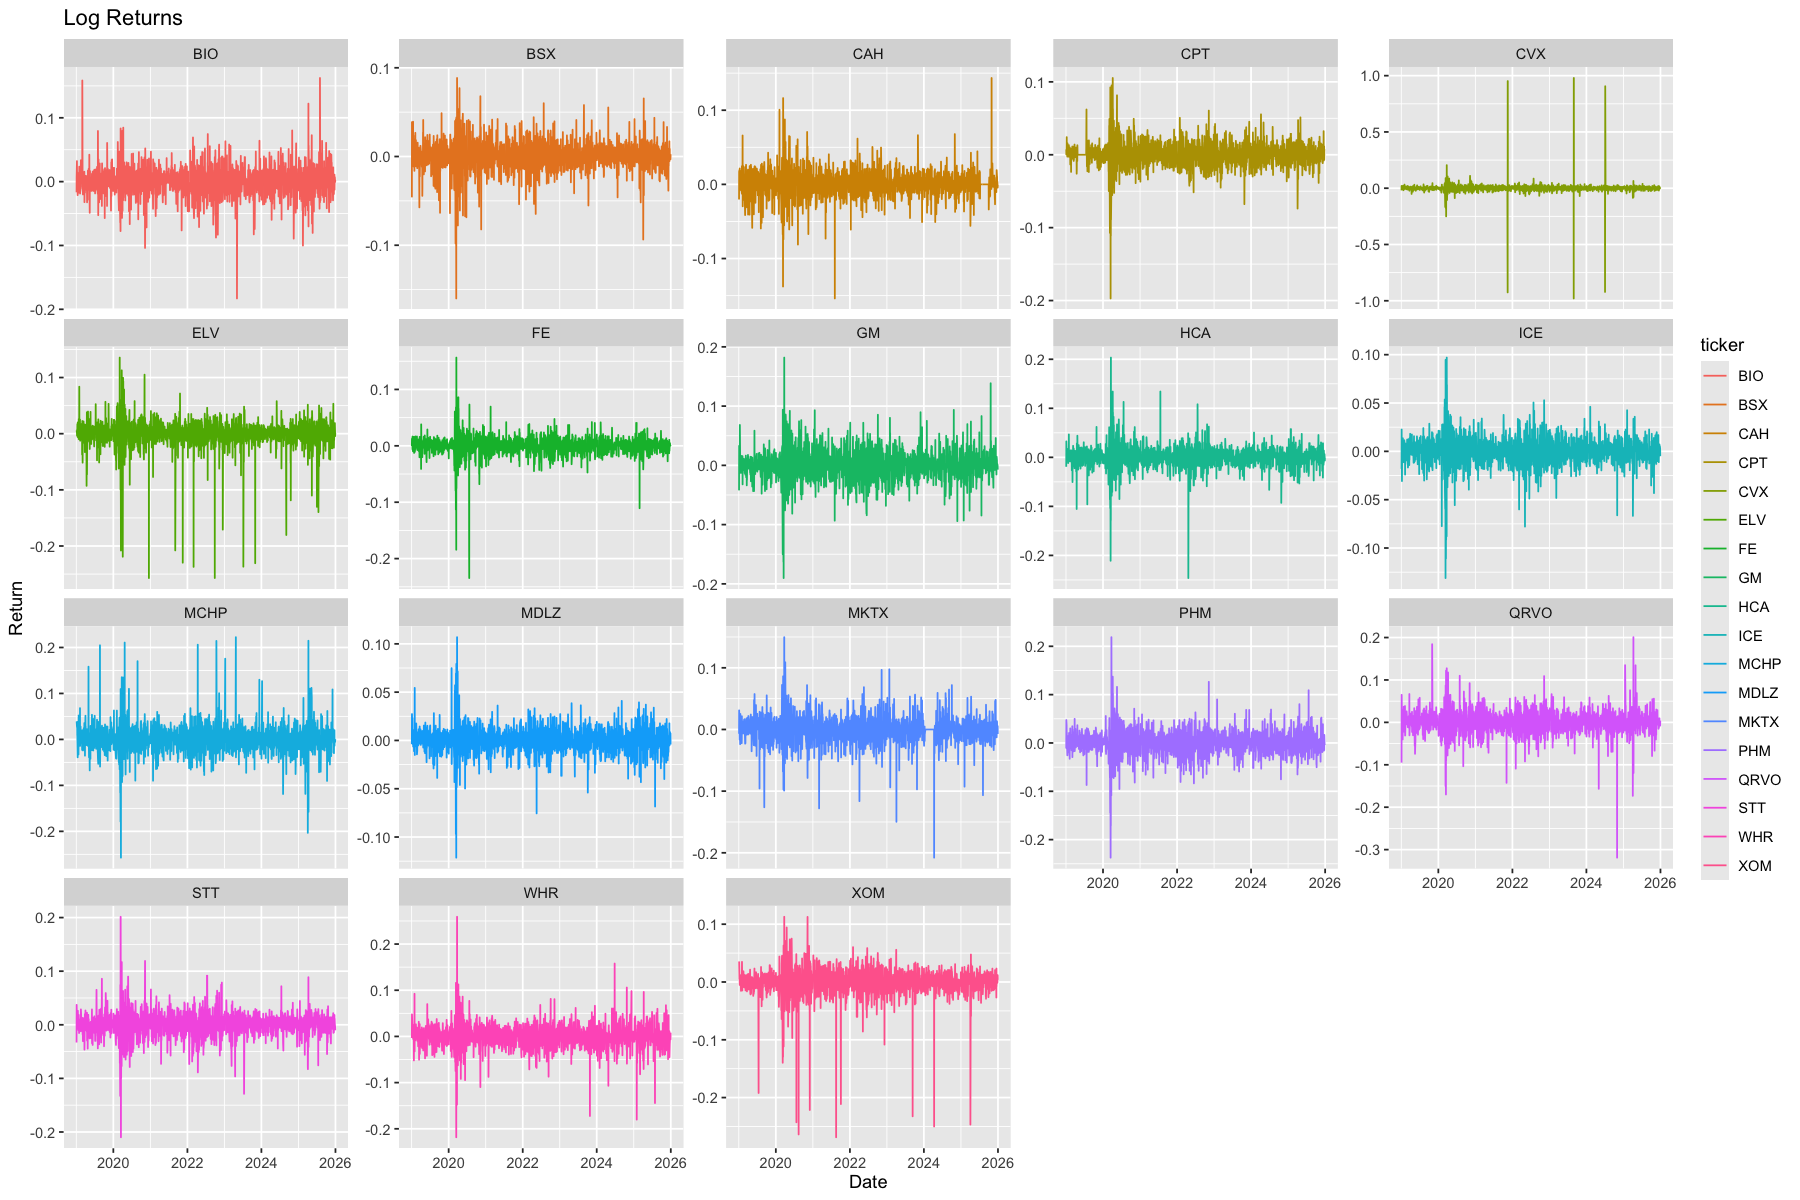

In [10]:
#combine the returns into a long data frame for ggplot2
rets_long <- do.call(rbind, lapply(names(rets_list), function(name) {
    data.frame(
        Date=rets_list[[name]]$Date,
        rets=rets_list[[name]]$rets,
        ticker=name
    )
}))

options(repr.plot.width=15, repr.plot.height=10)
ggplot(rets_long, aes(x=Date, y=rets, color=ticker)) +
    geom_line() + 
    facet_wrap(~ticker, scales="free_y") +
    labs(title="Log Returns", x="Date", y="Return")

From the plots, we observe that it is quite common to have daily retuns of &plusmn; 10-20%, even 30%. 

Nevertheless, `CVX` particularly stands out as it has several spikes of &plusmn; ~100% magnitude - likely a data issue.

### 3. Summary Statistics

In [11]:
desc_stat <- do.call(rbind, lapply(names(rets_list), function(name){
    r <- rets_list[[name]]$rets
    data.frame(
        ticker = name,
        mean = mean(r),
        sd = sd(r),
        min = min(r),
        max = max(r),
        skew = skewness(r),
        kurt = kurtosis(r)
    )
}))

format(desc_stat, scientific=FALSE, digits=2)

,ticker,mean,sd,min,max,skew,kurt
,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>
1,BIO,0.000164,0.023,-0.18,0.162,-0.021,6.9
2,CPT,0.000289,0.017,-0.20,0.105,-0.916,16.3
3,ELV,-0.001211,0.027,-0.26,0.136,-3.711,31.0
4,FE,0.000278,0.017,-0.23,0.156,-2.670,42.1
5,HCA,0.000807,0.022,-0.25,0.203,-0.835,20.5
6,MKTX,-0.000040,0.022,-0.21,0.150,-0.829,9.9
7,STT,0.000529,0.023,-0.21,0.201,-0.382,11.4
8,XOM,-0.000902,0.026,-0.27,0.113,-4.048,36.4
9,BSX,0.000584,0.017,-0.16,0.088,-0.898,8.3


As expected, `CVX` is a clear outlier, with kurtosis of ~228 and extreme min (-98%) and max (98%) values.

Other larger leptokurtic tickers include: `FE`, `ELV` and `XOM`, all with kurtosis above 30.
They are also the most largely skewed - likely affected by real negative events. However, `CVX` does not have a skew of high magnitude (minimal), which suggests that it is most likely a data issue.

There do not appear to be other exteme or unusual statistics.

,Date,rets,rets_simple
,<date>,<dbl>,<dbl>
724,2021-11-15,-0.9256495,-0.6037261
725,2021-11-16,0.9520014,1.5908898
1170,2023-08-29,-0.9795360,-0.6245147
1171,2023-08-30,0.9793483,1.6627205
1381,2024-07-03,-0.9216510,-0.6021384
1382,2024-07-05,0.9059602,1.4743066


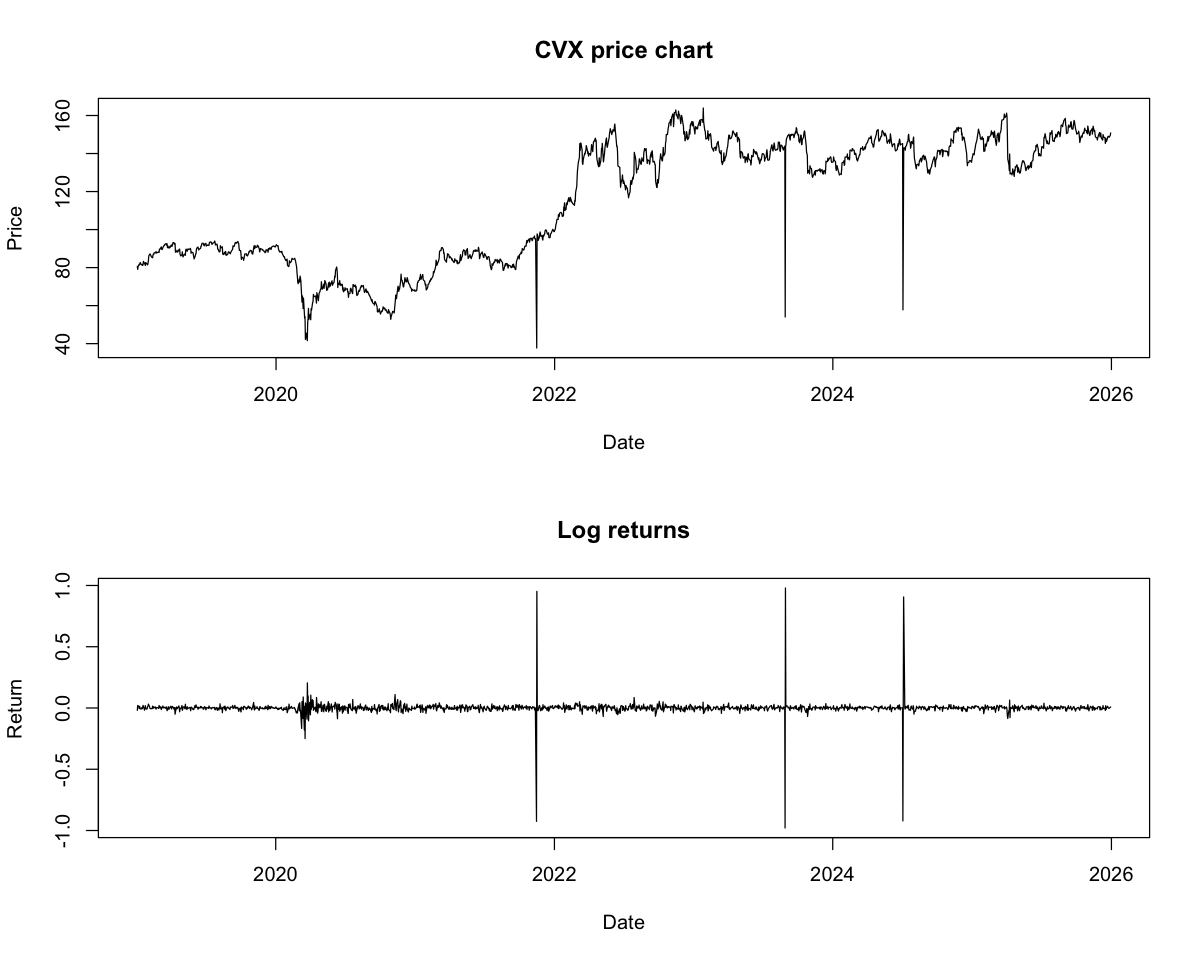

In [12]:
options(repr.plot.width=10, repr.plot.height=8)
par(mfrow=c(2,1))

plot(price_list[["CVX"]]$Date, price_list[["CVX"]]$Close, 
    type='l', main="CVX price chart", xlab="Date", ylab="Price"
)

plot(rets_list[["CVX"]]$Date, rets_list[["CVX"]]$rets, 
    type='l', main="Log returns", xlab="Date", ylab="Return"
)

rets_list[["CVX"]][abs(rets_list[["CVX"]]$rets) > 0.5, ] #to get the exact dates of the outlier dates

Upon further inspection, it can be seen that on 3 occasions, the stock price drops drastically and then recovers the next day. One possibility of such price change would be innapropriate stock split data handling, however `CVX` last stock split was in 2004. As such, it seems that the issue is simply wrong data entry.

To ensure appropriate return modelling and comparison, we trim those observations. Winsorizing would be innapropriate as making an estimate of the returns on those days would affect the return distribution. Given that we have established that those observations are not true outliers, but data handling errors, we find it most appropriate to simply remove them. Trimming at the 50% absolute value of returns is appropriate as no true observations exceed this amount, only the wrong entries.

In [13]:
rets_list[["CVX"]] <- rets_list[["CVX"]][abs(rets_list[["CVX"]]$rets) < 0.5, ] #keep only ret < 50% in magnitude

Mean: 0.0003522917 
SD: 0.02043079 
Min: -0.2500552 
Max: 0.2049111 
Skewness: -1.132913 
Kurtosis: 26.62659

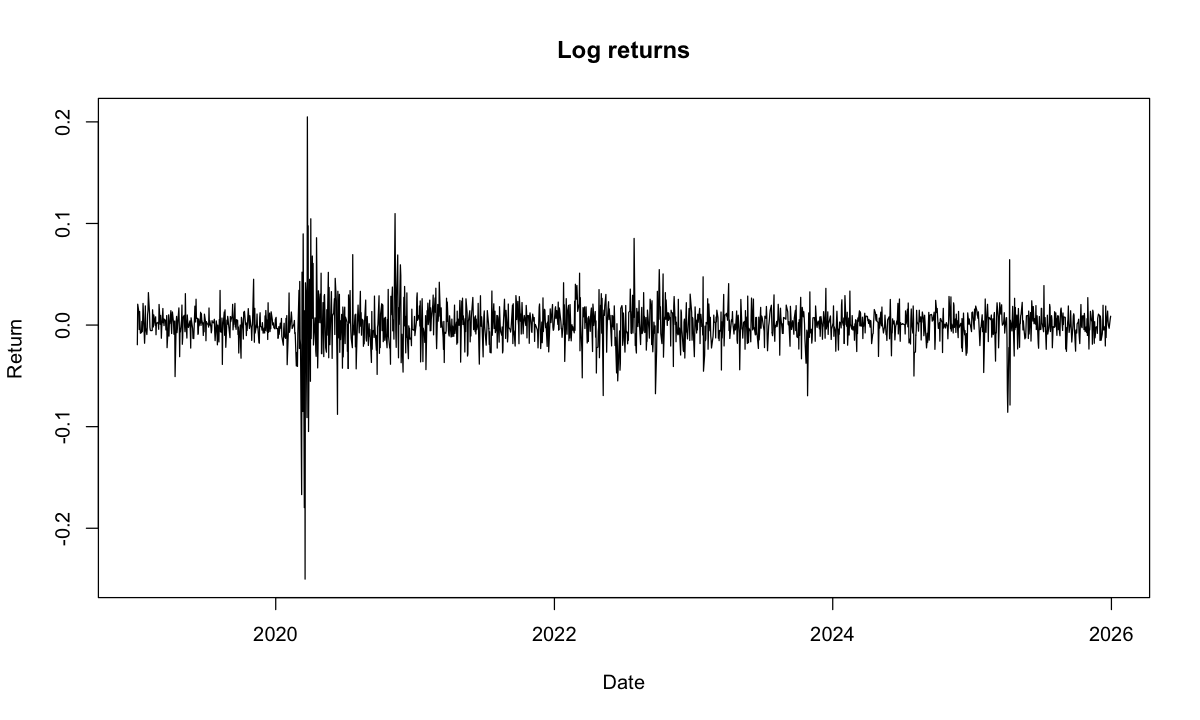

In [14]:
options(repr.plot.width=10, repr.plot.height=6)
plot(rets_list[["CVX"]]$Date, rets_list[["CVX"]]$rets, 
    type='l', main="Log returns", xlab="Date", ylab="Return"
)

CVX <- rets_list[["CVX"]]$rets
cat("Mean:", mean(CVX), 
    "\nSD:", sd(CVX), 
    "\nMin:", min(CVX), 
    "\nMax:", max(CVX), 
    "\nSkewness:", skewness(CVX), 
    "\nKurtosis:", kurtosis(CVX)
)

The issue is fixed.

Still, kurtosis is close to 30 and skewness has a magnitude above 1. 

Nevertheless, we will further investigate the ticker with highest kurtosis out of the sample, as the one to be the furthest away from a normal distribution. This is because kurtosis signals fat tails - extreme events happen more frequently, meanwhile negative skew (what we see in most stocks) simply suggests that most of the density is in a negative area.

### 4. Normality

We identify `FE` to be the ticker with highest lepptokurtic properties (45.2).

agg_record_67450954 
                  2


Title:
 Stable Parameter Estimation 

Call:
 .qStableFit(x = x, doplot = doplot, title = title, description = description)

Model:
 Stable Distribution

Estimated Parameter(s):
       alpha         beta        gamma        delta 
 1.559000000 -0.219000000  0.007255068  0.001612289 



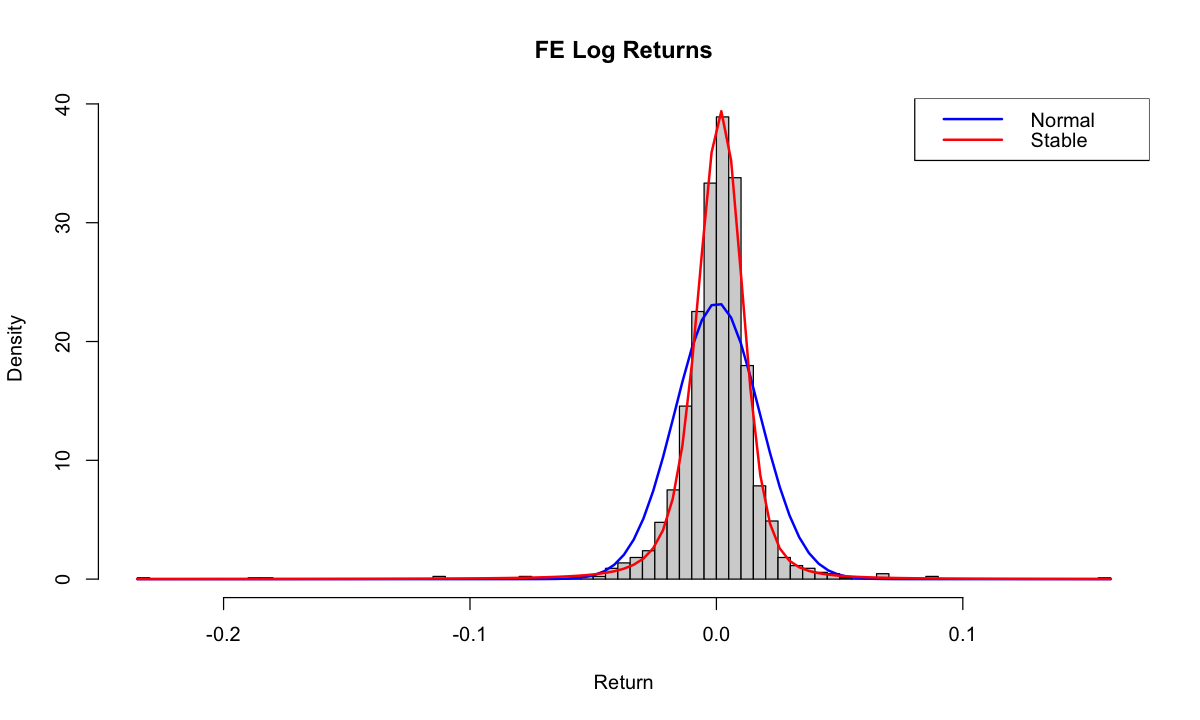

In [15]:
FE <- rets_list[["FE"]]$rets #plotting log returns - more likely to be normal than simple returns

pdf(NULL) #because stableFit produces an unnecessary graph
stable_param <- stableFit(FE, type="q") #fit the stable distrib (get the parameters)
dev.off()

print(stable_param)
hist(FE, breaks=100, freq=FALSE, main="FE Log Returns", xlab="Return")

curve(dnorm(x, mean=mean(FE), sd=sd(FE)), add=TRUE, col="blue", lwd=2) #normal distrib 

curve(dstable(x,alpha=stable_param@fit$estimate[1], #stable distrib
                beta=stable_param@fit$estimate[2],
                gamma=stable_param@fit$estimate[3],
                delta=stable_param@fit$estimate[4]),
    add=TRUE, col="red", lwd=2
)

legend("topright", legend=c("Normal", "Stable"), col=c("blue", "red"), lwd=2)

- Alpha: tail heaviness 
- Beta: skewness
- Gamma: scale (similar to sd)
- Delta: location (similar to mean)

The stable distribution parameters indicate significant tail risk, slight negative skewness and a location of near zero.

It is evident that using a normal distribution to model `FE`'s stock returns would be greatly inappropriate. The probability of an extreme negative shock to the stock price is much larger than the normal distribution predicts. This can have large implications on portfolio risk management. If the normal distribution is used to model a portfolio return distribution with large kurtosis (and negative skewness), risk measures such as Value at Risk and Expected Shortfall could be largely understated. Failing to appropriately account for tail risk could have devastating consequences. A clearer image of the left tail can be seen below.

The fitted stable distribution has $\alpha$ < 2, which implies a theoretically infinate variance. As such, in practice it comes at a cost. Risk measurement requires some sort of finate second moments.


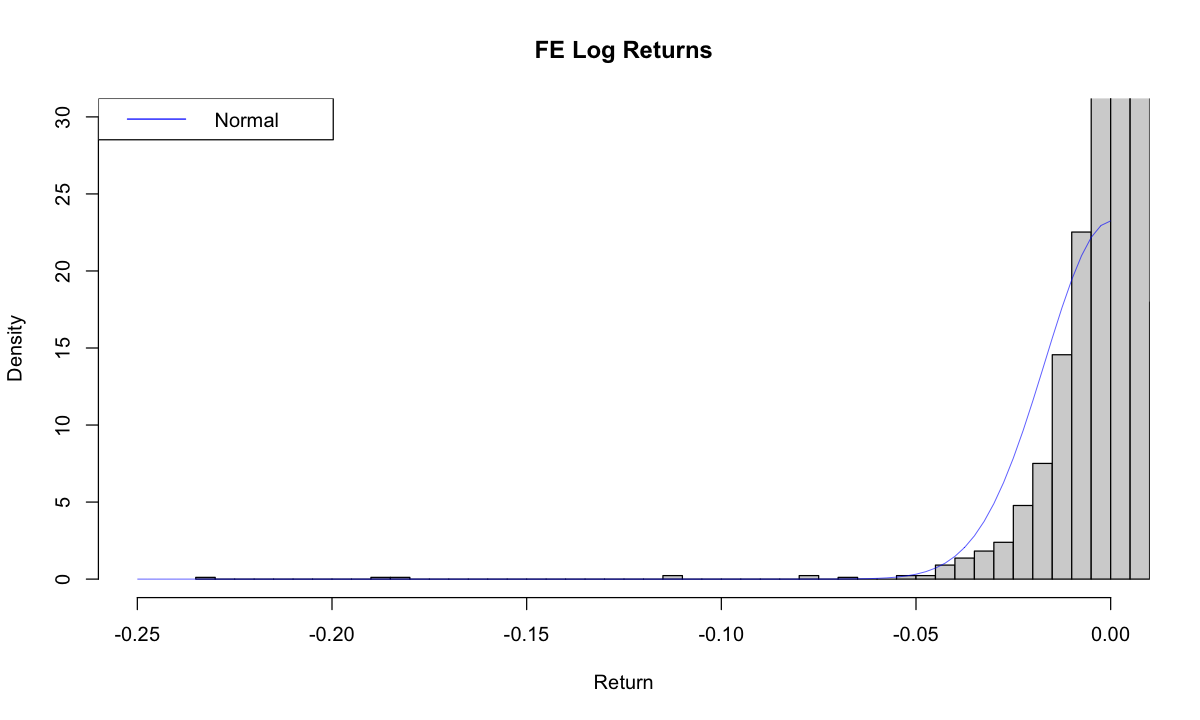

In [16]:
hist(FE, breaks=100, freq=FALSE, main="FE Log Returns", xlab="Return", xlim=c(-0.25, -0), ylim=c(0, 30))
curve(dnorm(x, mean=mean(FE), sd=sd(FE)), add=TRUE, col="blue", lwd=0.5)
legend("topleft", legend="Normal", col="blue", lwd=1)

### Part 2

,Date,rets,ticker
,<date>,<dbl>,<chr>
1,2019-01-03,-0.016712003,BIO
2,2019-01-04,0.008788729,BIO
3,2019-01-07,0.032136693,BIO
4,2019-01-08,0.007928430,BIO
5,2019-01-09,0.007781811,BIO
6,2019-01-10,0.014637264,BIO


In [23]:
inner_dates <- rets_long %>%
    select(Date, ticker, rets) %>%
    pivot_wider(names_from=ticker, values_from=rets) %>% #dates as rows, tickers as cols
    drop_na() #leave only matching date obs
head(inner_dates)


Date,BIO,CPT,ELV,FE,HCA,MKTX,STT,XOM,BSX,CAH,CVX,GM,ICE,MCHP,MDLZ,PHM,QRVO,WHR
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2019-01-04,0.008788729,0.0004616358,0.005962085,0.012445575,0.032530526,0.0309935488,0.037124053,0.035561637,0.038741436,0.017052254,0.020519126,0.03294290,0.022588184,0.038990434,0.027298329,0.047433789,0.064886681,0.047745304
2019-01-07,0.032136693,0.0025871697,0.001757424,0.012578330,0.008476227,0.0118739504,0.012382799,0.005183693,0.006119792,0.019409199,0.012915161,0.03042969,-0.030739133,0.028447993,0.006817683,0.036421425,0.006882109,0.028742367
2019-01-08,0.007928430,0.0241339677,-0.003566975,0.014219341,0.013963698,-0.0007875557,0.004304719,0.007216438,0.027508898,0.015160825,-0.004376643,0.01302332,-0.016898084,0.026438003,0.023080465,0.004612959,-0.006882109,0.022230804
2019-01-09,0.007781811,0.0020562433,0.007521231,-0.006038900,0.016584267,-0.0165173271,0.022863122,0.005253965,0.014033348,0.001731602,0.013327510,0.01055897,0.004009780,0.038134802,-0.003551100,0.021299819,0.018027529,0.023070472
2019-01-10,0.014637264,0.0121780018,0.003644675,0.016476458,0.011238573,-0.0022038826,-0.004037830,-0.005145588,0.001949047,0.021447083,0.001586946,-0.01285417,0.004685402,0.010027106,0.009721362,-0.011798111,0.023057190,0.008361940
2019-01-11,0.002280786,0.0033811530,0.017028889,-0.005450366,-0.004714046,-0.0003787295,0.007480560,-0.004605714,-0.010907674,0.000000000,-0.008057650,0.06816363,0.004379263,0.006630441,-0.002603694,-0.001055489,0.029153797,0.004718361


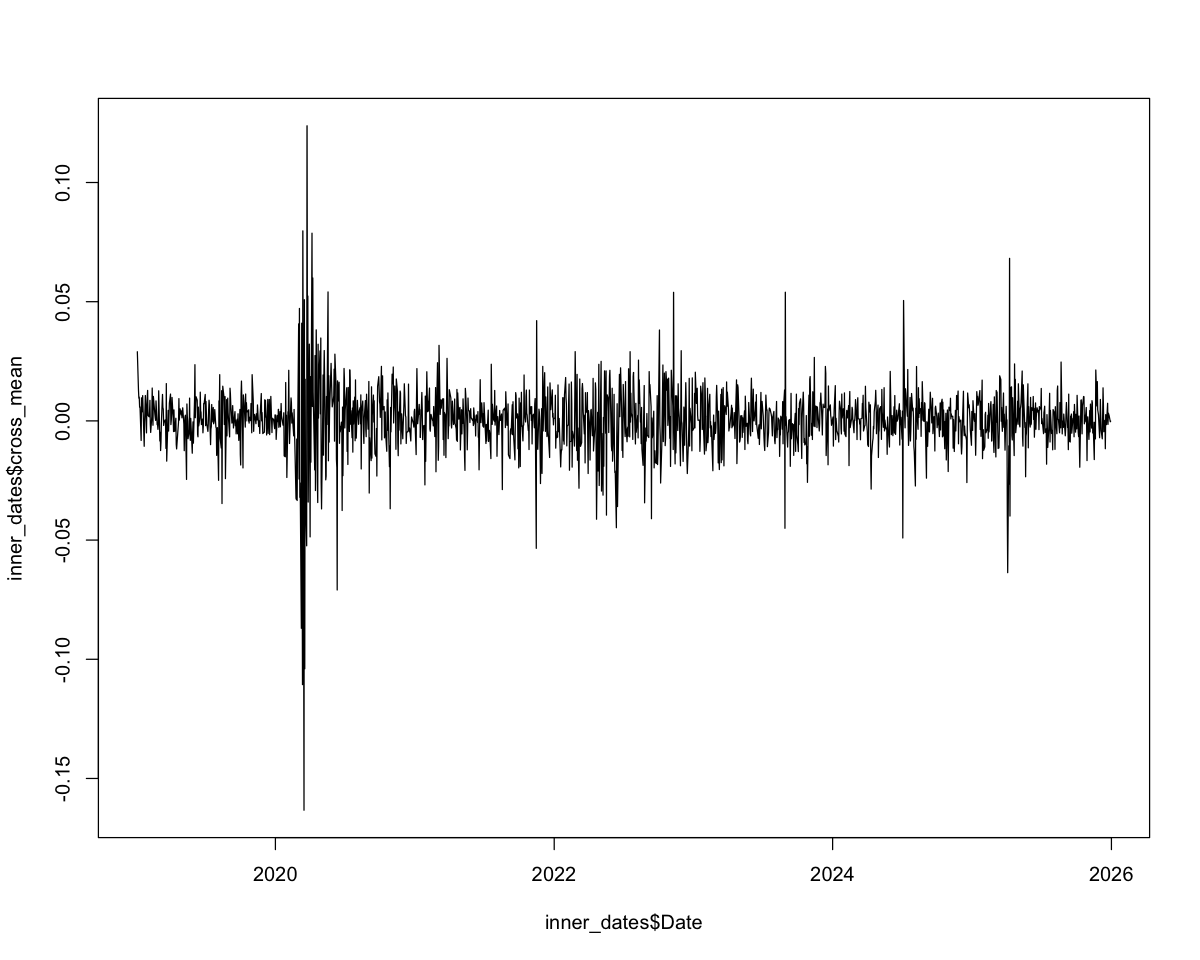

In [37]:
inner_dates$cross_mean <- rowMeans(inner_dates[, -1]) # -1] to not mean the date column
plot(inner_dates$cross_mean, x=inner_dates$Date, type="l")

agg_record_1650756872 
                    2

Cross: 1.562 -0.148 0.006386199 0.0008212003 
FE: 1.559 -0.219 0.007255068 0.001612289

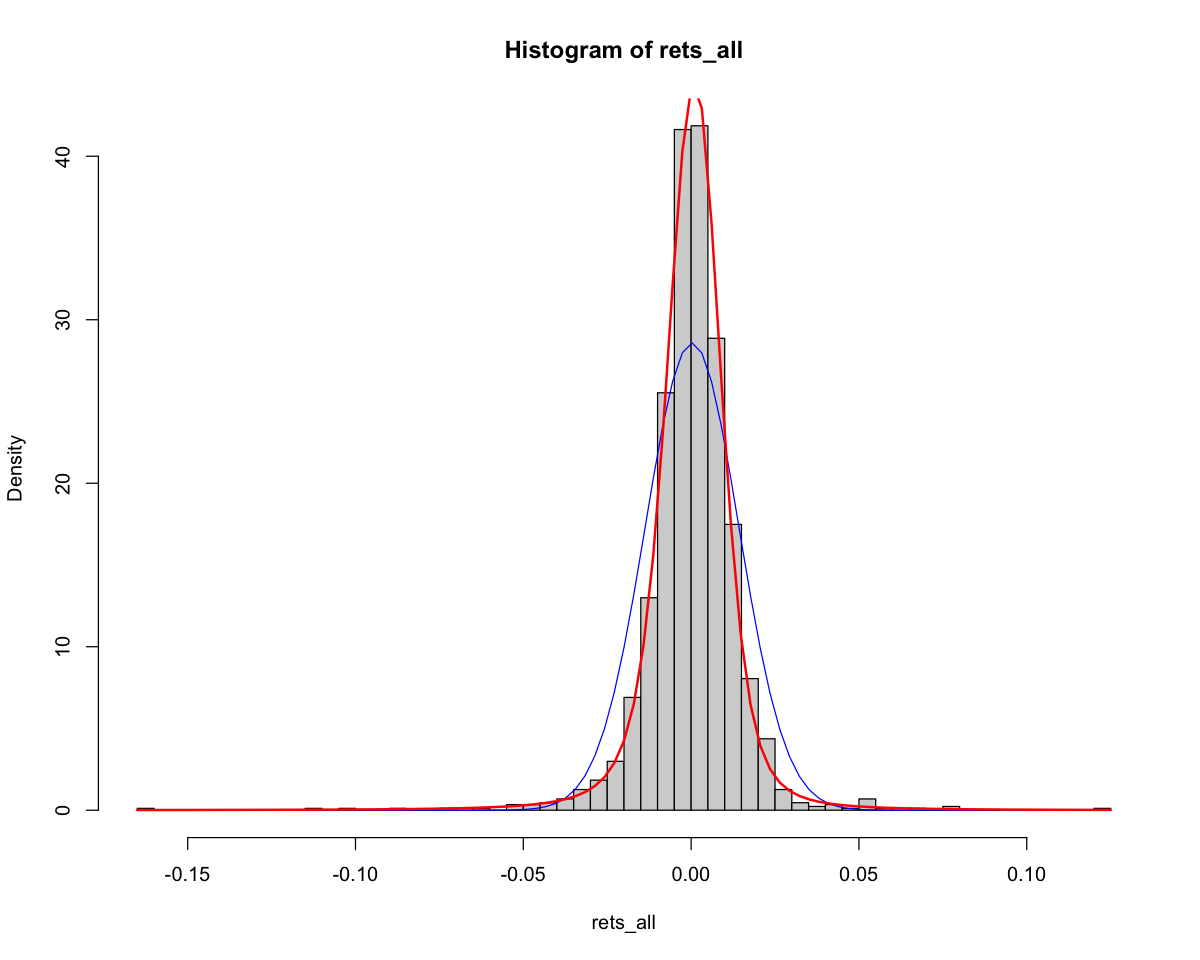

In [49]:
rets_all <- inner_dates$cross_mean

pdf(NULL)
stable_param_all <- stableFit(rets_all, type='q')
dev.off()

cat("Cross:", stable_param_all@fit$estimate, "\nFE:", stable_param@fit$estimate)
hist(rets_all, breaks=100, freq=FALSE)

curve(dnorm(x, mean=mean(rets_all), sd=sd(rets_all)), add=TRUE, col="blue")
curve(dstable(x,
                alpha=stable_param_all@fit$estimate[1],
                beta=stable_param_all@fit$estimate[2],
                gamma=stable_param_all@fit$estimate[3],
                delta=stable_param_all@fit$estimate[4]),
            add=TRUE, col="red", lwd=2
)

In [ ]:
cross_stat <- data.frame( #diversification
    ticker="Cross-mean",
    mean = mean(rets_all),
    sd = sd(rets_all),
    min = min(rets_all),
    max = max(rets_all),
    skew = skewness(rets_all),
    kurt = kurtosis(rets_all)
)

desc_stat_all <- rbind(desc_stat, cross_stat)
format(desc_stat_all, scientific=FALSE, digits=2)

,ticker,mean,sd,min,max,skew,kurt
,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>
1,BIO,0.000164,0.023,-0.18,0.162,-0.021,6.9
2,CPT,0.000289,0.017,-0.20,0.105,-0.916,16.3
3,ELV,-0.001211,0.027,-0.26,0.136,-3.711,31.0
4,FE,0.000278,0.017,-0.23,0.156,-2.670,42.1
5,HCA,0.000807,0.022,-0.25,0.203,-0.835,20.5
6,MKTX,-0.000040,0.022,-0.21,0.150,-0.829,9.9
7,STT,0.000529,0.023,-0.21,0.201,-0.382,11.4
8,XOM,-0.000902,0.026,-0.27,0.113,-4.048,36.4
9,BSX,0.000584,0.017,-0.16,0.088,-0.898,8.3


### Problem 2

In [56]:
library('tseries')

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



In [66]:
set.seed(123)
l <- 1001

rws_low <- matrix(ncol=500, nrow=l)
for (j in 1:ncol(rws_low)){
    e_low <- rnorm(l, sd=0.01)
    rws_low[1, j] <- 0
    for (i in 2:l){
        rws_low[i,j] <- rws_low[i-1, j] + e_low[i]
    }
}

rws_high <- matrix(ncol=500, nrow=l)
for (j in 1:ncol(rws_high)){
    e_high <- rnorm(l, sd=0.1)
    rws_high[1, j] <- 0
    for (i in 2:l){
        rws_high[i,j] <- rws_high[i-1, j] + e_high[i]
    }
}

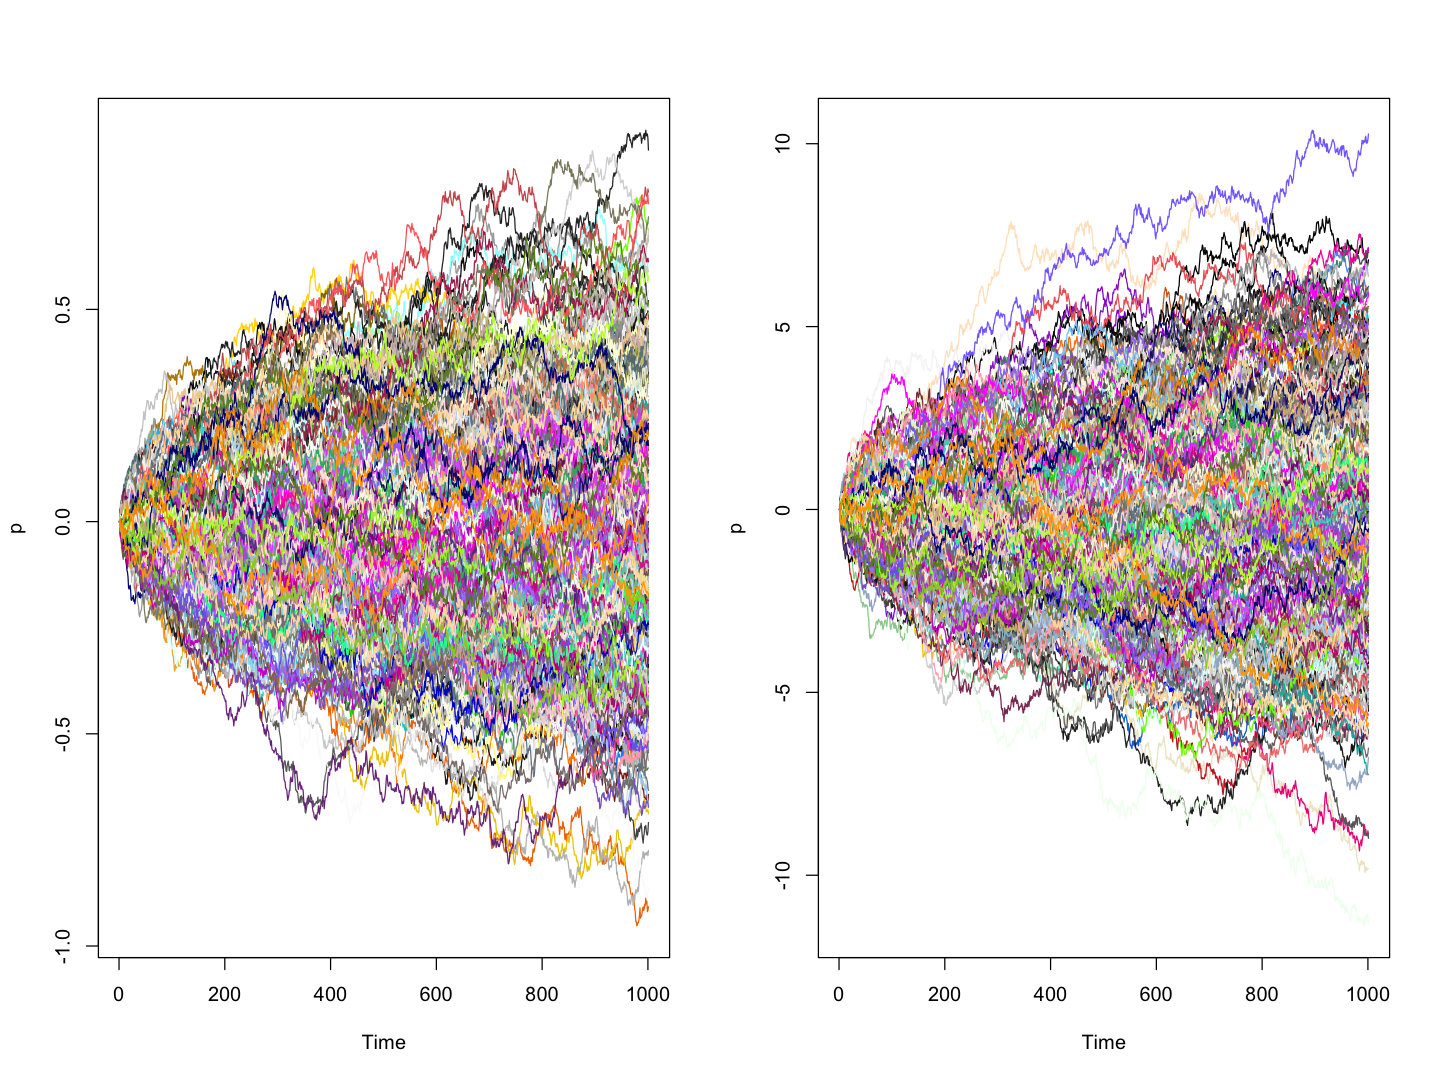

In [67]:
options(repr.plot.width = 12, repr.plot.height = 9)
par(mfrow=c(1,2))

plot.ts(rws_low[, 1], ylim=c(min(rws_low), max(rws_low)), ylab='p') #low var
for (j in 2:ncol(rws_low)){
    lines(rws_low[, j], col=colors()[j])
}

plot.ts(rws_high[, 1], ylim=c(min(rws_high), max(rws_high)), ylab='p') #high var
for (j in 2:ncol(rws_high)){
    lines(rws_high[, j], col=colors()[j])
}

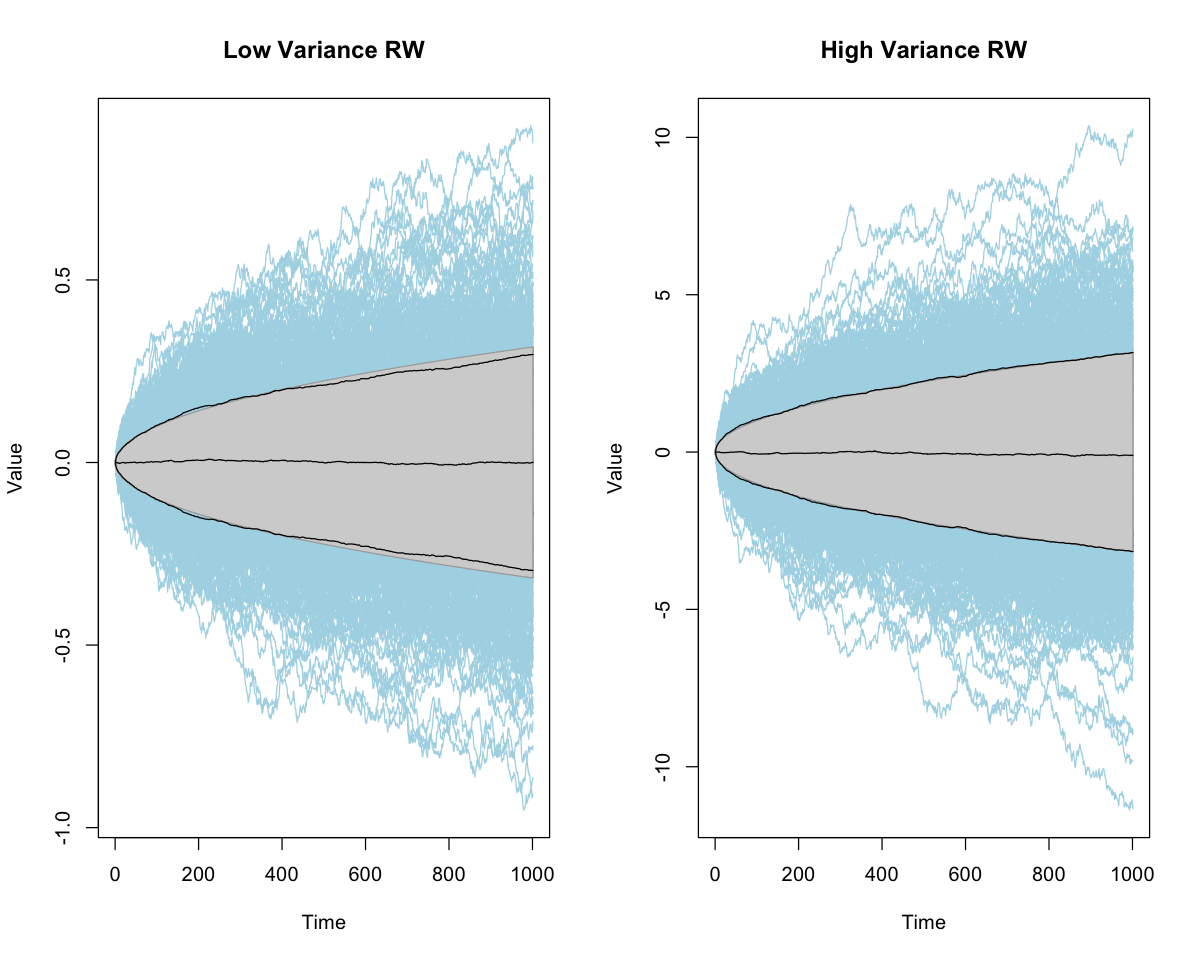

In [81]:
options(repr.plot.width = 10, repr.plot.height = 8)
par(mfrow=c(1,2))

#Low var
x<- c(0:l, l:0)
y <- c(c(0, sqrt(seq(1,l,1))*0.01), rev(c(0, -sqrt(seq(1,l,1))*0.01)))

plot(x, y, ylim=c(min(rws_low), max(rws_low)), type="l",
    main="Low Variance RW", xlab="Time", ylab="Value")
for(j in 1:ncol(rws_low)){
    lines(rws_low[, j], col="lightblue")
}
polygon(x, y, col="lightgray", border="darkgray") #theoretical
lines(apply(rws_low, 1, mean), col="black") #acc
lines(sqrt(apply(rws_low, 1, var)), col="black")
lines(-sqrt(apply(rws_low, 1, var)), col="black")

#High var
x<- c(0:l, l:0)
y <- c(c(0, sqrt(seq(1,l,1))*0.1), rev(c(0, -sqrt(seq(1,l,1))*0.1)))

plot(x, y, ylim=c(min(rws_high), max(rws_high)), type="l",
    main="High Variance RW", xlab="Time", ylab="Value")
for(j in 1:ncol(rws_high)){
    lines(rws_high[, j], col="lightblue")
}
polygon(x, y, col="lightgray", border="darkgray") #theoretical
lines(apply(rws_high, 1, mean), col="black") #acc
lines(sqrt(apply(rws_high, 1, var)), col="black")
lines(-sqrt(apply(rws_high, 1, var)), col="black")